<img src="images/logo/selene-logo-640.png" style="max-height:75px;" alt="SELENE Logo" />

**Disclaimer:** This Jupyter Notebook contains content generated with the assistance of AI. While every effort has been made to review and validate the outputs, users should independently verify critical information before relying on it. The SELENE notebook repository is constantly evolving. We recommend downloading or pulling the latest version of this notebook from Github.

# Activation Functions

Activation functions are a central building block of neural networks, yet their role is often easier to appreciate through motivation than through formal definitions alone. 
The key idea behind activation functions is to inject **non-linearity** into the network. Real-world data and relationships such as images, language, and time series, are rarely linear. By applying a non-linear activation function after each linear layer, neural networks gain the ability to approximate complex functions and capture intricate patterns in data. This is what allows deep learning models to solve challenging tasks such as image recognition, machine translation, and speech processing. Without activation functions, even the deepest network would collapse into a simple linear model with very limited expressive power.

From a practical perspective, activation functions also influence how information flows through the network and how effectively it can be trained. Different activation functions (such as ReLU, sigmoid, or tanh) have different properties that affect gradient propagation, training stability, and convergence speed. Choosing an appropriate activation function can make a significant difference in how well a model learns and how efficiently it can be optimized.

Understanding activation functions is therefore essential for anyone studying neural networks. They are not just a technical detail, but a fundamental concept that explains why deep learning works at all. By learning how and why activation functions are used, you build intuition about model capacity, expressiveness, and training dynamics. Such insights will be valuable when designing, analyzing, or improving neural network architectures.

### Setting up the Notebook

#### Make Required Imports

This notebook requires the import of different Python packages but also additional Python modules that are part of the repository. If a package is missing, use your preferred package manager (e.g., [conda](https://anaconda.org/anaconda/conda) or [pip](https://pypi.org/project/pip/)) to install it. If the code cell below runs with any errors, all required packages and modules have successfully been imported.

In [1]:
import torch
import torch.nn as nn

from src.utils.plotting.activations import *

#### Preliminaries

* This notebook assumes a basic understanding of calculus and the chain rules, including the general concept of backpropagation train neural networks.
* This notebook motivates and introduces the concept of activation functions but does not provide a comprehensive overview to existing functions; although we cover several popular instances.

---

## Motivation: The Need for Activation Functions


### The Underlying Math

At their core, neural networks are composed of layers that perform linear transformations, i.e., matrix multiplications followed by bias additions. If we were to stack many such linear layers without any additional processing, the entire network would still behave like a single linear transformation. This severely limits what the model can represent, regardless of how many layers it has. To better illustrate this, consider the following simple neural network consisting of two hidden layers and an output layer.

<img src="images/illustrations/activations/ann-example-no-activations.png" style="margin:auto;max-width:600px;width:100%" alt="Example Network without Activations" />

<br />

In this figure, $z_{i}^{j}$ denotes the output $i$-th neuron in the $j$-th layer; with $j=3$ being the index of the output layer. Note that we use $z$ to denote the pre-activation output of a neuron in line with common conventions. By combining all $z_{i}^{j}$ into vector $\mathbf{Z}^{j}$, we can define the ouput of each layer using the following equations:

$$
\begin{align}
\large \mathbf{z}^{(1)} &\large = \mathbf{W}^{(1)}\mathbf{x} + \mathbf{b}^{(1)}\\[0.5em]
\large \mathbf{z}^{(2)} &\large = \mathbf{W}^{(2)}\mathbf{z}^{(1)} + \mathbf{b}^{(2)}\\[0.5em]
\large \mathbf{z}^{(3)} &\large = \mathbf{W}^{(3)}\mathbf{z}^{(2)} + \mathbf{b}^{(3)}
\end{align}
$$

Next, we can express the final output $\mathbf{z}^{(3)}$ using a single formula be replacing $\mathbf{z}^{(2)}$ and $\mathbf{z}^{(2)}$ with their respective expressions.

$$
\begin{align}
\large \mathbf{z}^{(3)}\ &\large = \mathbf{W}^{(3)}\mathbf{z}^{(2)} + \mathbf{b}^{(3)}\\[0.5em]
&\large =  \mathbf{W}^{(3)}\left(\mathbf{W}^{(2)}\mathbf{z}^{(1)} + \mathbf{b}^{(2)}\right) + \mathbf{b}^{(3)}\\[0.5em]
&\large =  \mathbf{W}^{(3)}\left(\mathbf{W}^{(2)}\left(\mathbf{W}^{(1)}\mathbf{x} + \mathbf{b}^{(1)}\right) + \mathbf{b}^{(2)}\right) + \mathbf{b}^{(3)}
\end{align}
$$

Last, let's rewrite the equation by distributing all components that are outside of parentheses.

$$\large
\begin{align}
\large \mathbf{z}_{3}\ &\large = \mathbf{W}^{(3)}\left(\mathbf{W}^{(2)}\left(\mathbf{W}^{(1)}\mathbf{x} + \mathbf{b}^{(1)}\right) + \mathbf{b}^{(2)}\right) + \mathbf{b}^{(3)}\\[0.5em]
 &\large = \mathbf{W}^{(3)}\left(\mathbf{W}^{(2)}\mathbf{W}^{(1)}\mathbf{x} + \mathbf{W}^{(2)}\mathbf{b}^{(1)} + \mathbf{b}^{(2)}\right) + \mathbf{b}^{(3)}\\[0.5em]
 &\large = \mathbf{W}^{(3)}\mathbf{W}^{(2)}\mathbf{W}^{(1)}\mathbf{x} + \mathbf{W}^{(3)}\mathbf{W}^{(2)}\mathbf{b}^{(1)} + \mathbf{W}^{(3)}\mathbf{b}^{(2)} + \mathbf{b}^{(3)}
\end{align}
$$

We can now apply the rules of linear transformations to further rewrite the equation. Firstly, the composition of linear transformations (here: $\mathbf{W}^{(3)}\mathbf{W}^{(2)}\mathbf{W}^{(1)}\mathbf{x}$ and $\mathbf{W}^{(3)}\mathbf{W}^{(2)}\mathbf{b}^{(1)}$) is itself a linear transformation, which can always be represented by one matrix. And secondly, The sum of linear transformations is itself also a linear transformation because it preserves the two defining properties of linearity: additivity and homogeneity. This allows us to define a new weight matrix $\mathbf{W}^\prime$ and bias vector $\mathbf{b}^\prime$ as:

$$\large
\begin{align}
\large \mathbf{W}^\prime\ &\large = \mathbf{W}^{(3)}\mathbf{W}^{(2)}\mathbf{W}^{(1)}\\[0.5em] 
\large \mathbf{b}^\prime\ &\large = \mathbf{W}^{(3)}\mathbf{W}^{(2)}\mathbf{b}^{(1)} + \mathbf{W}^{(3)}\mathbf{b}^{(2)} + \mathbf{b}^{(3)}
\end{align}
$$

Thus, we can now compute $\mathbf{z}_{3}$ as:

$$\large 
\mathbf{z}_{3} = \mathbf{W}^\prime\mathbf{x} + \mathbf{b}^\prime
$$

In other words, we can compute $\mathbf{z}_{3}$ single linear layer. This holds true independent of the initial number of layers (in our example: $3$). No matter the number of layers, without non-linear activation functions **all layers collapse to a single linear layer**, and the network's capacity to learn does not increase by simply adding more layers. Activation functions break this collapse by introducing non-linearity, thus making them indispensable when building deep networks. Without them, the network cannot model complex relationships such as curves, interactions, or decision boundaries that are not straight lines (or hyperplanes in higher dimensions). As a result, a network without activation functions can only learn linear mappings, severely limiting its ability to solve real-world problems where patterns are inherently non-linear.

### A Practical Example

Although the math is clear and easy to understand, let's actually look at a concrete example that shows the importance of activation functions to learn non-linear problems. To this end, the code cell below creates a simple quadratic dataset of $200$ data points for a very basic non-linear function. Feel free to change the function that computes `y` to any other more or less complex function and see how it affects the results.

In [2]:
np.random.seed(0)
# Create X values
X = np.linspace(-2, 2, 200).reshape(-1, 1)
# Create y values with randmon noise
y = X**2 + 0.25 * np.random.randn(*X.shape)

We provide the auxiliary method `plot_example_data()` to plot the data; just run the code cell below.

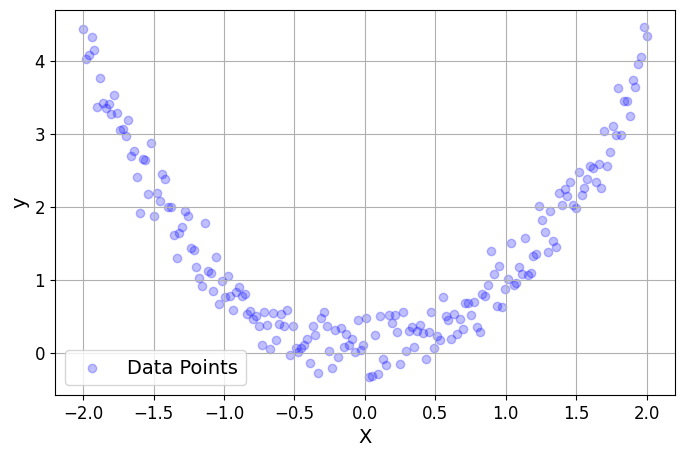

In [3]:
plot_example_data(X, y)

We can now try training different neural network &mdash; with or without activation functions &mdash; to learn this target function. We are using PyTorch for this and must therefore convert our inputs and targets to PyTorch tensors to serve as valid arguments for the models.

In [4]:
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

Since we consider several network models, we also define the auxiliary method `train()` that trains a given model using the generated dataset. This method performs the standard training loop for a neural network using PyTorch. It first initializes the Adam optimizer with the model’s parameters and a specified learning rate, and defines the loss function as Mean Squared Error (MSE), which measures how far predictions are from the true targets. For each epoch, the model makes predictions on the input data `X`, computes the loss against the true values `y`, and then clears any previously stored gradients using `optimizer.zero_grad()`. Next, `loss.backward()` computes gradients of the loss with respect to all model parameters via backpropagation, and `optimizer.step()` updates those parameters in the direction that reduces the loss. Repeating this process over many epochs gradually improves the model’s performance by minimizing prediction error.

In [5]:
def train(model, X, y, epochs=1000, lr=0.01):
    # Define optimizer with set learning rate
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # Define loss functions
    loss_fn = nn.MSELoss()
    # Train model for set number of epochs
    for epoch in range(epochs):
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

**(1) 2-Layer network WITH activation function.** Let's first consider a simple 2-layer network &mdash; one hidden layer and one output layer &mdash; with a non-linear activation between them. In the code cell below, we use the Sigmoid function as the non-linearity (which will be covered later in the notebook) but you can also try other activation functions such as Tanh or ReLU as indicated by the commented lines in the code example. Again, no worries if you do not know these functions as we will briefly discuss them later.

In [6]:
model_2layer_activation = nn.Sequential(
    nn.Linear(1, 32),
    nn.Sigmoid(),
    #nn.Tanh(),
    #nn.ReLU(),
    nn.Linear(32, 1)
)

# Train the model
train(model_2layer_activation, X, y)

To see how our model performs, we use the model to predict the output for all training samples, and then plot the predictions as a regression line using the auxiliary method `plot_example_data()` again. The code cell below the model in inference mode using PyTorch. The `with torch.no_grad():` context disables gradient tracking, which makes computation faster and reduces memory usage since no gradients are needed during prediction. Inside this block, the model `model_2layer_activation` processes the input `X` to produce predictions, and `.numpy()` converts the resulting tensor into a NumPy array so it can be used outside of PyTorch (e.g., for analysis or visualization).

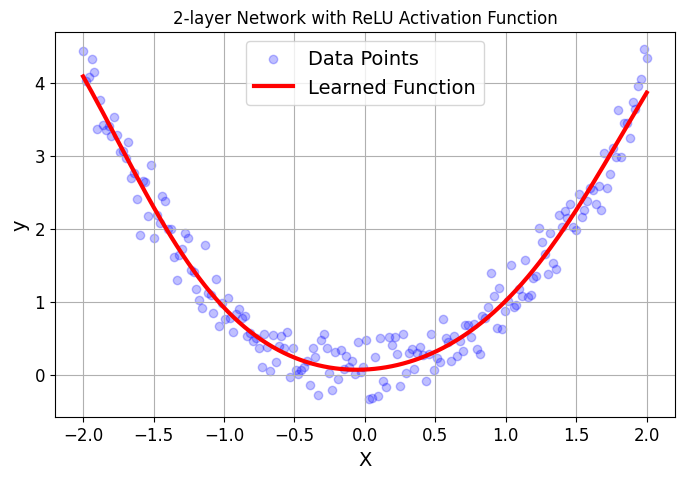

In [7]:
with torch.no_grad():
    y_pred = model_2layer_activation(X).numpy()

plot_example_data(X, y, y_pred, y_pred_label="Learned Function", title="2-layer Network with ReLU Activation Function")

It is clear from the plot that the model has successfully learned to approximate the target function. After all, this should not be too surprising since the target function is very simple, and arguably would not need a neural network to approximate it. However, the purpose of this simple model is to serve as a baseline for comparing the results for models without activation functions.

**(2) 2-Layer network WITHOUT activation function.** Let's create a new model by modifying the previous model where the only change we make is to remove the activation function between the hidden about the output layer; the size of the hidden layer remains the same. Using the `train()` method we train this model as well.

In [8]:
model_2layer_noactication = nn.Sequential(
    nn.Linear(1, 32),
    nn.Linear(32, 1)
)

# Train the model
train(model_2layer_noactication, X, y)

As before, we can now use the model to predict the output values for the training data and plot the results.

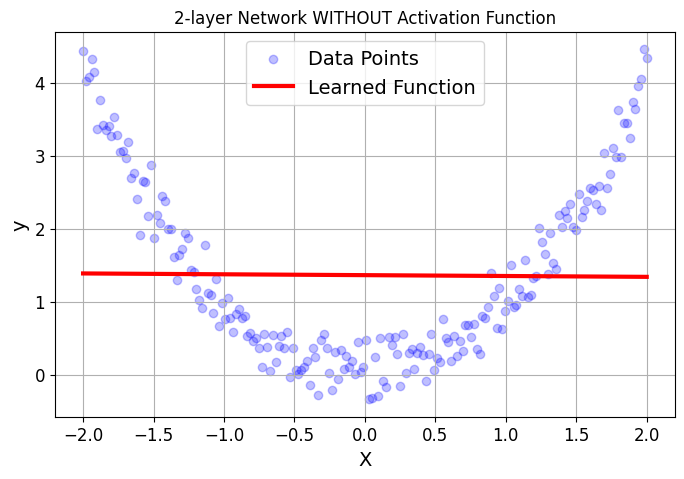

In [9]:
with torch.no_grad():
    y_pred = model_2layer_noactication(X).numpy()

plot_example_data(X, y, y_pred, y_pred_label="Learned Function", title="2-layer Network WITHOUT Activation Function")

We can see that the model is only capable of learning a linear function since the absence of an activation function means that the $2$ linear layers have collapsed into a single linear layer. Again, appreciate that the only change we made to the original model was to remove the activation function!

**(2) 10-Layer network WITHOUT activation functions.** Lastly, to show the number of layers really does not matter if we do not use activation functions, the code cell below creates and trains a $10$-layer network &mdash; $9$ hidden layers and $1$ output layer &mdash; with no activation function between two layers.

In [10]:
model_10layer_noactication = nn.Sequential(
    nn.Linear(1, 4),
    nn.Linear(4, 16),
    nn.Linear(16, 32),
    nn.Linear(32, 64),
    nn.Linear(64, 128),
    nn.Linear(128, 64),
    nn.Linear(64, 32),
    nn.Linear(32, 16),
    nn.Linear(16, 4),
    nn.Linear(4, 1)
)

train(model_10layer_noactication, X, y)

To plot the result, like before, we use the trained model to predict the outputs for the training samples.

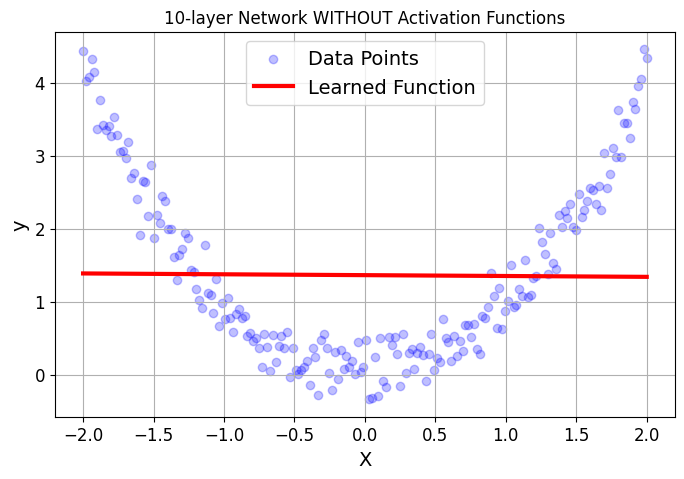

In [11]:
with torch.no_grad():
    y_pred = model_10layer_noactication(X).numpy()

plot_example_data(X, y, y_pred, y_pred_label="Learned Function", title="10-layer Network WITHOUT Activation Functions")

In a nutshell, the plots for the 2-layer network and the 10-layer network (both without activation functions) are essentially identical since in both models, all linear layers collapse into a single one. This also means that, beyond rounding errors both networks learn the same function. Even with $100$ or more layers this would not change; they still would collapse into a single linear layer. So once again, we need activation functions to enable neural networks to learn any non-linear functions to solve real-world tasks.

---

## Types of Activation Functions

### Elementwise Functions

Elementwise activations refer to the application of a non-linear function to each individual component of a vector, matrix, or tensor. For example, a linear layer computing $\mathbf{z} = \mathbf{W}\mathbf{x} + \mathbf{b}$ will return a vector of the form $\mathbf{z} = [z_1, z_2, z_3, \dots, z_d]^\top$, where $d$ is the dimensions of the layer in terms of the number of neurons. Elementwise activation functions apply a non-linear function to each individual output $z_i$ independently.

#### Basic Definitions

Mathematically, given our output vector $\mathbf{z} = [z_1, z_2, z_3, \dots, z_d]^\top$, the output of an elementwise activation function $\phi$ is defined as &mdash; we use the common notation of $\mathbf{a}$ to refer the result vector containing all activations:

$$\large
\mathbf{a} = \phi(\mathbf{z}) = 
\begin{bmatrix}
\phi(z_1)\\
\phi(z_2)\\
\phi(z_3)\\
\vdots\\
\phi(z_d)\\
\end{bmatrix}
$$

Of course, $\mathbf{a}$ is itself a vector of the form $\mathbf{a} = [a_1, a_2, a_3, \dots, a_d]^\top$. Later, we will look at some concrete examples for the activation function $\phi$.

Compting $\phi(\mathbf{z})$ is done as part of the forward pass both during inference and training. For the training, however, we also need to compute the derivative of $\phi$ to perform backpropagation through the activation functions. Since $\phi$ has multiple inputs $z_1, z_2, z_3, \dots, z_d$ and multiple inputs $a_1, a_2, a_3, \dots, a_d$, we need to compute the Jacobian $J$, i.e., the matrix containing all partial derivatives $\large \frac{\partial a_i}{\partial z_j}$.

$$\large
J =\frac{\partial \mathbf{a}}{\partial \mathbf{z}} = 
\begin{bmatrix}
\frac{\partial a_1}{\partial z_1} & \frac{\partial a_1}{\partial z_2} & \frac{\partial a_1}{\partial z_1} & \dots & \frac{\partial a_1}{\partial z_d}\\
\frac{\partial a_2}{\partial z_1} & \frac{\partial a_2}{\partial z_2} & \frac{\partial a_2}{\partial z_3} & \dots & \frac{\partial a_2}{\partial z_d}\\
\frac{\partial a_3}{\partial z_1} & \frac{\partial a_3}{\partial z_2} & \frac{\partial a_3}{\partial z_3} & \dots & \frac{\partial a_3}{\partial z_d}\\
\vdots & \vdots & \vdots & \ddots & \vdots \\
\frac{\partial a_d}{\partial z_1} & \frac{\partial a_d}{\partial z_2} & \frac{\partial a_d}{\partial z_3} & \dots & \frac{\partial a_d}{\partial z_d}\\
\end{bmatrix}
$$

However, this Jacobian immediately simplifies because we know that an output $a_i$ only depends on input $z_i$, and not on any other input $z_j$ &mdash; this is the definition of an elementwise activation function after all! This means that all partial derivatives $\large \frac{\partial a_1}{\partial z_1}$ are $0$ of $i\neq j$. In other words, only the partial derivatives on the main diagonal of the Jacobian are non-zero. Thus, we can write $J$ as:

$$\large
J = \frac{\partial \mathbf{a}}{\partial \mathbf{z}} = 
\begin{bmatrix}
\frac{\partial a_1}{\partial z_1} & 0 & 0 & \dots & 0\\
0 & \frac{\partial a_2}{\partial z_2} & 0 & \dots & 0\\
0 & 0 & \frac{\partial a_3}{\partial z_3} & \dots & 0\\
\vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & \dots & \frac{\partial a_d}{\partial z_d}\\
\end{bmatrix}
$$

For convenience, we can also use Langrange or Prime notation to write the Jacobian. This allows us to express $J$ using the common $\text{diag}$ function, which creates a diagonal matrix with the vector elements on the diagonal and zeros elsewhere &mdash; exactly the format of $J$.

$$\large
J =  
\begin{bmatrix}
\phi^\prime(z_1) & 0 & 0 & \dots & 0\\
0 & \phi^\prime(z_2) & 0 & \dots & 0\\
0 & 0 & \phi^\prime(z_3) & \dots & 0\\
\vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & \dots & \phi^\prime(z_d)\\
\end{bmatrix} = \text{diag}\left(\phi(\mathbf{z}) \right)
$$

$\phi^\prime$ is simply the derivative of activation function $\phi$, and we see some examples later in the notebook. During backpropagation, we need to compute the gradient of loss $\mathcal{L}$ with respect to $\mathbf{z}$, i.e., $\large \frac{\partial \mathcal{L}}{\partial \mathbf{z}}$, as part of the backward pass. We do this by applying the chain rule of calculus to get:

$$\large
\frac{\partial \mathcal{L}}{\partial \mathbf{z}} = \frac{\partial \mathcal{L}}{\partial \mathbf{a}} \frac{\partial \mathbf{a}}{\partial \mathbf{z}} = \frac{\partial \mathcal{L}}{\partial \mathbf{a}} \text{diag}\left(\phi^\prime(\mathbf{z}) \right)
$$

where $\large \frac{\partial \mathcal{L}}{\partial \mathbf{a}} = \left[\frac{\partial \mathcal{L}}{a_1}, \frac{\partial \mathcal{L}}{a_2}, \frac{\partial \mathcal{L}}{a_3}, \dots, \frac{\partial \mathcal{L}}{a_d} \right]^\top$ is the upstream gradient we receive as input for the activation function &mdash; input with respect of the backward pass. As we see later, most activation functions $\phi$ are defined to yield "convenient" derivatives $\phi^\prime$. This makes backpropgating though elementwise activation functions generally quite straightforward and efficient. In fact, in practice, we never have to actually materialize the full diagonal matrix, since multiplying a vector &mdash; here, the upstream gradient $\large \frac{\partial \mathcal{L}}{\partial \mathbf{a}}$ &mdash; with a diagonal matrix &mdash; here, the Jacobian $\text{diag}\left(\phi(\mathbf{z}) \right)$ &mdash; can be expressed as the elementwise product of both both vectors $\large \frac{\partial \mathcal{L}}{\partial \mathbf{a}}$ and $\phi(\mathbf{z})$. We can there write:

$$\large
\frac{\partial \mathcal{L}}{\partial \mathbf{z}} = \frac{\partial \mathcal{L}}{\partial \mathbf{a}} \odot \phi^\prime(\mathbf{z})
$$

where $\odot$ is the Hadamard product (also known as the elementwise product, entrywise product, or pointwise product. Or, written in the Leibniz notation, we get:

$$\large
\frac{\partial \mathcal{L}}{\partial \mathbf{z}} = \frac{\partial \mathcal{L}}{\partial \mathbf{a}} \odot \frac{\partial \mathbf{a}}{\partial \mathbf{z}}
$$

In short, elementwise activation functions make both the forward pass and the backward pass quite straightforward. During the forward pass, we simply compute the activation for each neuron without worrying about interactions between different neurons. Regarding the backward pass, the derivative of the activation function with respect to its input is computed independently for each neuron, and gradients can be multiplied elementwise with the upstream gradients. As a result, both forward and backward computations remain highly efficient and parallelizable, which is one reason why elementwise activations are widely used in practice.

#### Common Examples

Over time, researchers and practitioners have proposed a wide variety of activation functions, each designed to address specific challenges in training neural networks. Some aim to improve gradient flow, others to speed up convergence, and others to enhance numerical stability or performance in very deep architectures &mdash; see a brief discussion further down below. As a result, there is no single "best" activation function, since each comes with its own advantages and drawbacks depending on the task, network architecture, and optimization setup. Despite this diversity, it is useful to start with a small set of foundational activation functions that illustrate the key ideas and trade-offs. In the following, we will focus on three of the most basic and widely used examples: Sigmoid, Tanh, and ReLU.

#####  Sigmoid

The Sigmoid activation function &mdash; often written as $\sigma(x)$ &mdash; is one of the earliest and most intuitive ways to introduce non-linearity into a neural network. It "squashes" any real-valued input into a range between $0$ and $1$, which makes it especially useful when we want to interpret outputs as probabilities (e.g., in binary classification). Historically, it was inspired by biological neurons, where outputs tend to saturate at minimum and maximum firing rates rather than growing unbounded. The Sigmoid function is defined as:

$$\large
\sigma(x) = \frac{1}{1 + e^{-x}} = \frac{e^x}{1 + e^x}
$$

This S-shaped (logistic) curve has a smooth gradient, which makes it differentiable and suitable for gradient-based optimization. As the Sigmoid function is mainly based on the exponential $e^x$, it is especially convenient because its derivatives have a very simple and elegant form. Omitting the full details here, the derivative of the Sigmoid functions is:

$$\large
\frac{d\sigma(x)}{dx} = \sigma(x)(1-\sigma(x))
$$

Activation functions are frequently based on the constant e primarily because of its unique relationship with calculus. In deep learning, training a model requires calculating gradients to update weights. This mathematical convenience significantly reduces the computational overhead during backpropagation, as the processor doesn't need to perform entirely new, complex calculations to find the gradient.

The code cell below implements the Sigmoid function as well as its derivative as Python methods using NumPy. Using the provided auxiliary method `plot_activation_function()` we can visualize both functions in a single plot to see their behavior.

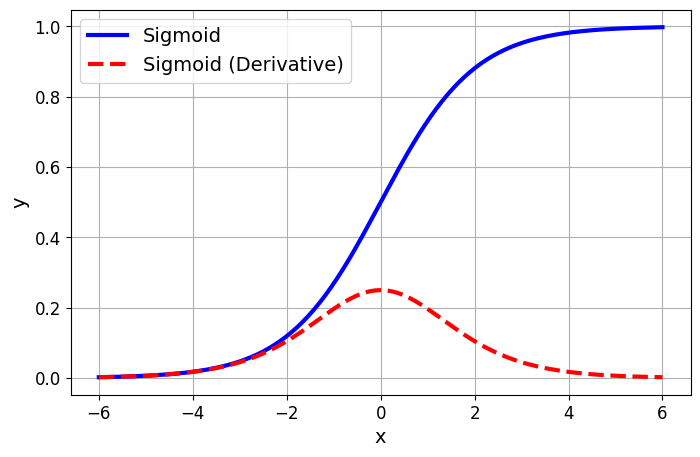

In [12]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def dsigmoid(x):
    return sigmoid(x) * (1 - sigmoid(x))

plot_activation_function(sigmoid, dsigmoid, label="Sigmoid")

Appreciate the how both the Sigmoid and its derivative behave to compare with the plots for other activation functions, but also do better understand the follow-up discussion about general characteristics &mdash; some desired, some undesired &mdash; of activations functions and their effects on training large neural networks.

##### Tanh (Hyperbolic Tangent)

The Tanh (hyperbolic tangent) activation function is closely related to the Sigmoid but improves on one of its key limitations. Like sigmoid, it introduces non-linearity and smoothly squashes inputs, but instead of mapping values to the range $[0,1]$, Tanh maps them to $[-1,1]$. This zero-centered output is important in neural networks because it helps balance positive and negative signals during training, often leading to faster convergence and more stable optimization. The Tanh function is defined as follows:

$$\large
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$

Like the Sigmoid, the Tanh function is based on the exponential $e^x$, which again yields a very "convenient" function for its derivative:

$$\large
\frac{d\tanh(x)}{dx} = 1 - \tanh(x)^2
$$

Let's define both the Tanh and its derivative as Python methods and plot them using the `plot_activation_function()` method.

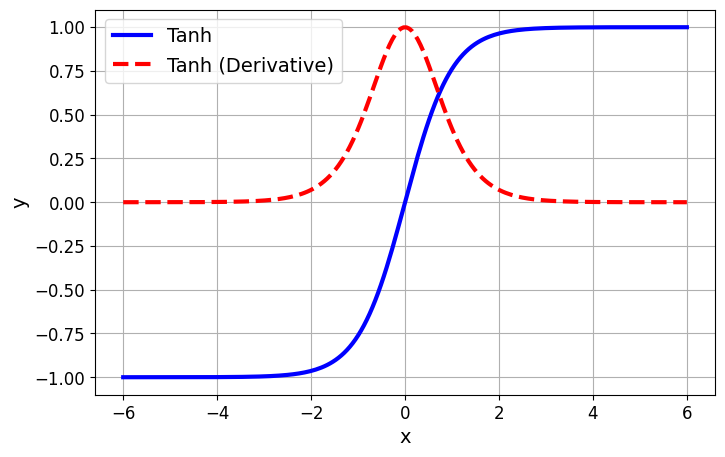

In [13]:
def tanh(x):
    return (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))

def dtanh(x):
    return 1 - tanh(x)**2

plot_activation_function(tanh, dtanh, label="Tanh")

The overall shapes of both functions are quite similar to the ones for the Sigmoid (and its derivative). However, we can clearly see the range of $[0, 1]$ for the Tanh function here, but also the derivative of the Tanh features large values compared to the derivative of the Sigmoid function.

##### ReLU (Rectified Linear Unit)

The ReLU (Rectified Linear Unit) activation function is fundamentally different from Sigmoid and Tanh. Instead of smoothly squashing inputs into a bounded range, ReLU takes a much simpler approach: it outputs $0$ for all negative inputs and leaves positive inputs unchanged. Mathematically, we can define the ReLU function using as:

$$\large
\text{ReLU}(x) = \max(0, x)
$$

This simplicity of ReLU is also reflected in its derivative, which outputs $0$ for negative values and $1$ for positive values:

$$\large
\frac{d\ \text{ReLU}(x)}{dx} =
\begin{cases}
0, \text{ if } x < 0\\[0.5em]
1, \text{ if } x \geq 0\\[0.5em]
\end{cases}
$$

As for Sigmoid and Tanh, we can also implement both formulas as a Python method using NumPy. In case of the derivative, `drelu()` uses the NumPy notation `x > 0` to create a boolean array of the same shape as `x`, where each element is `True` if the corresponding element in `x` is greater than 0, and `False` otherwise. In other words, it identifies which inputs are in the **active region** of ReLU (where the output is non-zero and the gradient is 1). By applying `.astype(float)` it then  converts the boolean array into a float array, where `True` becomes $1.0$ and `False` becomes $0.0$. This corresponds exactly to the derivative of ReLU.

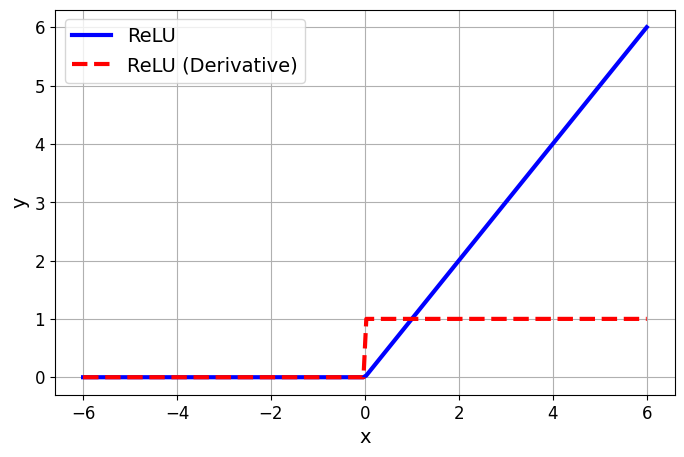

In [14]:
def relu(x):
    return np.maximum(0, x)

def drelu(x):
    return (x > 0).astype(float)

plot_activation_function(relu, drelu, label="ReLU")

At first glance, the ReLU activation function might seem like a risky or even crude choice. Unlike Sigmoid or Tanh, it is not smooth, it abruptly zeroes out all negative inputs, and it is unbounded for positive values. These characteristics could make it appear unstable or prone to problems during training. Additionally, the "dying ReLU" issue, where neurons can get stuck outputting zero if their inputs are always negative, adds another reason to doubt its suitability.

Despite these apparent drawbacks, ReLU has proven to work surprisingly well in practice. Its simplicity and piecewise linear structure allow gradients to propagate efficiently for positive inputs, which accelerates training and helps deep networks converge faster. Moreover, its computational efficiency and ability to mitigate vanishing gradients in deep layers make it highly effective across a wide range of architectures. This counterintuitive success highlights a key lesson in neural networks: even simple, seemingly imperfect functions can be extremely powerful when used in the right context.

#### Core Characteristics

While we just looked at three common activation functions &mdash; Sigmoid, Tanh, and ReLU &mdash; many more have been proposed and are being used by researchers and practitioners. This naturally raises the questions if and to what extent the choice of the activation functions matters. Fundamentally, they all serve the same purpose: introducing **non-linearities** into neural networks, i.e., the functions the networks describe. That being said, activation functions can be described by various characteristics that affect their behavior. Let's have a look at some of these core characteristics and see how the tree activation functions we have covered fit in.

* **Differentiability.** Training neural networks (mostly) relies on gradient-based optimization, specifically backpropagation. During training, the model computes how much each parameter contributed to the error by applying the chain rule of calculus, which requires taking derivatives of the activation functions. If an activation function is differentiable, it allows gradients to flow smoothly through the network, enabling efficient and stable updates to the weights. In practice, activation functions do not need to be perfectly differentiable everywhere, but they should be differentiable *almost everywhere* with well-defined gradients. For example, ReLU is not differentiable exactly at *0*, yet it works very well because this single point rarely causes issues during training. What matters more is that the function provides meaningful gradients across most input values. Sigmoid and Tanh are differentiable for any input.

* **Range and saturation.** The *range* of an activation function determines the scale of the outputs passed to the next layer; for instance, Sigmoid and Tanh are "squashing" functions that bound outputs between $[0, 1]$ or $[-1, 1]$, respectively. This prevents activations from exploding to infinite values. However, these finite ranges may lead to *saturation*, where the function becomes nearly flat at its extreme ends. When a neuron saturates, its derivative approaches $0$, causing the "vanishing gradient" problem. In this state, the network stops updating its weights effectively, essentially "dying" because the error signal can no longer propagate backward through the layers. Conversely, functions with an infinite range in at least one direction, such as ReLU, avoid saturation for positive inputs. This characteristic allows the gradient to remain constant (exactly $1.0$) for all positive values, which significantly accelerates convergence during training by maintaining a strong signal. The trade-off is that without a bounded range, the network is more susceptible to "exploding gradients" if the weights are not carefully initialized. Choosing between a saturated or non-saturated function is therefore a balancing act between ensuring numerical stability and maintaining a healthy flow of information during backpropagation.

* **Zero-centering.** When an activation function is not zero-centered (like the Sigmoid function, which only outputs values between $0$ and $1$), the outputs from a layer are always positive. During backpropagation, the gradient of the weights in the next layer depends on these activations. If all activations are positive, the gradients for all weights in a specific neuron will share the same sign (all positive or all negative). This constraint forces the weight updates to move in a restricted "zig-zag" pattern toward the optimal solution, rather than taking a direct path, which significantly slows down convergence. By using zero-centered functions like Tanh (range $-1$ to $1$), the internal activations have a mean closer to zero. This distribution allows the gradients to take on different signs, providing more "degrees of freedom" for weight updates. Consequently, the optimization process becomes much more stable and computationally efficient.

* **Computational efficiency.** In modern deep learning, models often consist of dozens of layers and millions or even billions of parameters. During both the forward pass (inference) and the backward pass (training), the activation function must be calculated for every single neuron across every layer. If a function involves complex operations like exponentials or natural logarithms (as seen in Sigmoid or Tanh), the cumulative hardware overhead becomes significant, leading to longer training times and higher energy costs. By contrast, functions like ReLU are often preferred in large-scale architectures because they are computationally "cheap". A ReLU operation requires only a simple threshold comparison at the processor level, which is much faster than computing power functions.

There generally is no single "best" activation function for all neural networks because the ideal choice depends on the architecture, task, and training dynamics. Different activation functions have different strengths and weaknesses &mdash; for example, some provide strong gradients but may be unstable, while others are smooth and bounded but prone to vanishing gradients. As a result, the effectiveness of an activation function is highly context-dependent, and what works well for one model (e.g., a shallow network or classification task) may not perform as well for another (e.g., very deep networks or generative models).

In practice, the choice of activation function is guided by a combination of empirical performance and established conventions. For hidden layers, simple and efficient functions like ReLU and its variants are often the default because they train quickly and work well in deep architectures. For output layers, the choice is typically tied to the task (e.g., Sigmoid for binary classification or Softmax for multiclass problems &mdash; see below). Beyond these defaults, practitioners often experiment with alternatives (such as GELU or Swish) and select the activation function that yields the best validation performance for their specific problem.

### Global (Non-Elementwise) Functions

In contrast to standard element-wise activations like Sigmoid, Tanh, or ReLU, **global (non-elementwise) activation functions** determine the output of a specific neuron based on the entire vector of input activations rather than processing each value in isolation. These functions introduce a form of competition or normalization across a layer, effectively coupling the units so that the activation of one neuron directly influences the potential activation of its neighbors. By looking at the collective state of the input vector, these functions can enforce specific mathematical constraints, such as ensuring the outputs sum to one or identifying the most dominant feature in a set.

#### Basic Definitions

As before, let's assume we have a vector $\mathbf{z} = [z_1, z_2, z_3, \dots, z_d]^\top$ that is given to a global activation function $f$ as input. With this, a global activation function defines the $i$-th component of the output as a function of the entire input vector $\mathbf{z}$; at least in principle. Mathematically, we can express this as follows:

$$\large
\mathbf{a} = f(\mathbf{z}) = 
\begin{bmatrix}
f_1(z_1, z_2, z_3, \dots, z_d)\\
f_2(z_1, z_2, z_3, \dots, z_d)\\
f_3(z_1, z_2, z_3, \dots, z_d)\\
\vdots\\
f_d(z_1, z_2, z_3, \dots, z_d)\\
\end{bmatrix}
$$

Since each output $a_1, a_2, a_3, \dots, a_d$ generally depends on all inputs $z_1, z_2, z_3, \dots, z_d$, the resulting Jacobian matrix $J$ no longer simplifies to a diagonal matrix since all partial derivatives $\large \frac{\partial a_i}{\partial z_j}$ are non-zero. Thus, for global activations functions, $J$ is a dense matrix:

$$\large
J =\frac{\partial \mathbf{a}}{\partial \mathbf{z}} = 
\begin{bmatrix}
\frac{\partial a_1}{\partial z_1} & \frac{\partial a_1}{\partial z_2} & \frac{\partial a_1}{\partial z_1} & \dots & \frac{\partial a_1}{\partial z_d}\\
\frac{\partial a_2}{\partial z_1} & \frac{\partial a_2}{\partial z_2} & \frac{\partial a_2}{\partial z_3} & \dots & \frac{\partial a_2}{\partial z_d}\\
\frac{\partial a_3}{\partial z_1} & \frac{\partial a_3}{\partial z_2} & \frac{\partial a_3}{\partial z_3} & \dots & \frac{\partial a_3}{\partial z_d}\\
\vdots & \vdots & \vdots & \ddots & \vdots \\
\frac{\partial a_d}{\partial z_1} & \frac{\partial a_d}{\partial z_2} & \frac{\partial a_d}{\partial z_3} & \dots & \frac{\partial a_d}{\partial z_d}\\
\end{bmatrix}
$$

Since each output component $a_i$ can depend on all input components $z_1, z_2, z_3, \dots, z_d$, during backpropagation, the gradient with respect to each input requires summing contributions from all output components:

$$\large
\frac{\partial \mathcal{L}}{\partial z_j} = \sum_{i=1}^{d} \frac{\partial \mathcal{L}}{\partial a_i} \frac{\partial a_i}{\partial z_j}.
$$

This introduces additional computational cost &mdash; often $\mathcal{O}(n^2)$ instead of $\mathcal{O}(n)$ &mdash; and requires more memory to store intermediate dependencies. Consequently, gradient computation is more complex and less parallelizable compared to the simple, independent updates in elementwise activation functions.

#### Example: Softmax

The Softmax function is arguably one of the most prominent and widely used instances of a global activation function. Softmax transforms a vector of real-valued scores (often called logits) into a probability distribution. Given an input vector $\mathbf{z} \in \mathbb{R}^n$, Softmax maps it to an output vector $\mathbf{a} \in \mathbb{R}^n$ where each component lies between $0$ and $1$ and all components sum to $1$. It does this by exponentiating each input and normalizing by the sum of all exponentials, ensuring that larger input values correspond to higher probabilities while still maintaining a consistent scale across the entire vector. Mathematical, the Softmax of a single output $\text{Softmax}(\mathbf{z})_{i}$:

$$\large
\text{Softmax}(\mathbf{z})_{i} = \frac{e^{z_i}}{\sum_{j=1}^{d} e^{z_j}}
$$

Or, in terms of all outputs, we can write:

$$\large
\text{Softmax}(\mathbf{z}) =
\begin{bmatrix}
\frac{e^{z_1}}{\sum_{j=1}^{d} e^{z_j}}\\
\frac{e^{z_2}}{\sum_{j=1}^{d} e^{z_j}}\\
\frac{e^{z_3}}{\sum_{j=1}^{d} e^{z_j}}\\
\vdots\\
\frac{e^{z_d}}{\sum_{j=1}^{d} e^{z_j}}
\end{bmatrix}
= \frac{1}{\sum_{j=1}^{d} e^{z_j}}
\begin{bmatrix}
e^{z_1}\\
e^{z_2}\\
e^{z_3}\\
\vdots\\
e^{z_d}
\end{bmatrix}
$$

The main purpose of Softmax is to make neural network outputs interpretable as probabilities over multiple classes, which is especially important in classification tasks. For example, in a model predicting categories (like digits, object classes, or sentiment labels), Softmax allows the network to express not just a single prediction, but a full distribution over all possible classes. This makes it possible to train the model using probabilistic loss functions such as Cross-Entropy, and to compare predictions in a meaningful way. Its global nature, where each output depends on all inputs, ensures that increasing the score of one class necessarily decreases the relative probability of others, reflecting the idea of competing hypotheses.

Using NumPy, we can implement the Softmax function as a simple Python method as shown in the code cell below.

In [15]:
def softmax(x):
    # Exponentiate all inputs
    exp_x = np.exp(x)
    # Normalize by dividing by sum of all exponentiated inputs
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

We can test this function by defining a NumPy array $z$ and apply the `softmax()` method to it:

In [16]:
z = np.asarray([-2.4, 0.9, -0.1])

a = softmax(z)

print(f"Softmax of {z}: {a} (Sum of all values in 'a': {np.sum(a)})")

Softmax of [-2.4  0.9 -0.1]: [0.0262558  0.71186405 0.26188015] (Sum of all values in 'a': 1.0)


Independent of the sign of the values in `z`, the Softmax function ensures that

* All output values are between $0$ and $1$
* All output values sum up to $1$
* The order of the elements is preserved (e.g., the largest values in `z` is the largest value in `a`, and so on)

Regarding the backward pass, the mathematical shift from elementwise activation functions to global activation functions such as Softmax is best understood by looking at the Jacobian matrix, which represents how every output in a layer changes in response to every input. Recall that in an elementwise activation (e.g., Sigmoid, Tanh, ReLU), the $i$-th output $a_i$ is a function solely of the $i$-th input $z_i$, meaning the derivative $\large \frac{\partial a_i}{\partial z_j}$ is zero whenever $i \neq j$. This results in a diagonal Jacobian, where the gradient "flows" through independent, parallel channels. This independence is computationally efficient but prevents neurons within the same layer from communicating or enforcing collective constraints.

In contrast, Softmax introduces a global denominator &mdash; the sum of all exponentiated inputs &mdash; which couples every output to every input. As a consequence, all partial derivatives $\large \frac{\partial a_i}{\partial z_j}$ are non-zero, making the Jacobian a dense, non-diagonal matrix. This non-diagonal structure is the algebraic signature of "competition" between neurons; it allows the network to learn that increasing the probability of one class must necessarily decrease the probability of others, a property that is mathematically impossible with a simple diagonal mapping. In short, we now have to compute the full Jacobian matrix $J$.

$$\large
J =\frac{\partial \mathbf{a}}{\partial \mathbf{z}} = 
\begin{bmatrix}
\frac{\partial a_1}{\partial z_1} & \frac{\partial a_1}{\partial z_2} & \frac{\partial a_1}{\partial z_1} & \dots & \frac{\partial a_1}{\partial z_d}\\
\frac{\partial a_2}{\partial z_1} & \frac{\partial a_2}{\partial z_2} & \frac{\partial a_2}{\partial z_3} & \dots & \frac{\partial a_2}{\partial z_d}\\
\frac{\partial a_3}{\partial z_1} & \frac{\partial a_3}{\partial z_2} & \frac{\partial a_3}{\partial z_3} & \dots & \frac{\partial a_3}{\partial z_d}\\
\vdots & \vdots & \vdots & \ddots & \vdots \\
\frac{\partial a_d}{\partial z_1} & \frac{\partial a_d}{\partial z_2} & \frac{\partial a_d}{\partial z_3} & \dots & \frac{\partial a_d}{\partial z_d}\\
\end{bmatrix}
$$

The derivative of the Softmax function is also a bit more involved because it is a vector-valued function (i.e., depending on all inputs $z_j$). Omitting all the detailed steps here &mdash; but which are covered in a separate notebook &mdash; For an input vector $\mathbf{z}$ with Softmax outputs $\mathbf{a} = \text{softmax}(\mathbf{z})$, the partial derivative derivative $\large \frac{\partial a_i}{\partial z_j}$ is:

$$\large
\frac{\partial a_i}{\partial z_j} = 
\begin{cases}
a_i(1-a_j), & i=j,\\
-a_i a_j, & i\neq j
\end{cases}
$$

However, again using NumPy, the full Jacobian matrix $J$ can be implemented as a short Python method:

In [17]:
def softmax_derivative(z):
    a = softmax(x).reshape(-1, 1)  # Column vector
    return np.diagflat(a) - np.dot(s, a.T)

In this method, `np.diagflat(a)` creates a diagonal matrix with `a_i` on the diagonal, and `np.dot(a, a.T)` computes the outer product of `a` with itself. Lastly, subtracting one from the other gives the Jacobian, which captures how each output depends on all inputs.

#### Alternatives

While the Softmax function is most common example of a global activation function, neural networks often contain other components or operations that are and or can be considered global activation functions; here is a brief overview:

* **Normalization Layers** like **Batch Normalization**, **Layer Normalization**, and **Group Normalization** are considered global activation functions because they calculate the output of a single neuron based on the collective statistics (specifically the mean and variance) of a larger group. This creates a mathematical coupling where the transformation of one value is directly dependent on the values of its neighbors within the same batch or layer. Because a change in one input alters the shared statistics and subsequently affects every output in the group, these layers possess the dense, non-diagonal Jacobian matrix characteristic of global operations. By aggregating information across dimensions, these functions act as structural activations that stabilize training.

* **Competitive hidden layers** are architectural components where neurons within the same layer compete with one another to be "active", mimicking the biological process of lateral inhibition. In a standard layer, every neuron processes its input independently via an element-wise activation. However, in a competitive layer, the activation of one neuron can suppress or modulate the signal of its neighbors. This is often achieved through global activation functions like **Maxout** or **Local Response Normalization (LRN)**, which force the network to select only the most prominent features from a local group. By making neurons compete for "representation space", the network naturally develops more specialized and sparse feature detectors. Instead of having many neurons redundantly learning the same pattern, competition encourages "winner-take-all" or "winner-take-most" dynamics. For example, in a Maxout layer, only the strongest linear projection in a group is passed forward, allowing the network to approximate complex, non-convex functions and become invariant to small changes in the input. This structural competition acts as a form of regularization, preventing the model from over-relying on a single noisy feature and forcing it to learn a more diverse set of internal representations.

---

## Summary

In this notebook, we introduced the concept of **activation functions**, a fundamental component of neural networks. Activation functions define how the output of a neuron is computed from its input and play a critical role in determining the expressive power of the network. Without activation functions, a neural network would be equivalent to a linear model, regardless of the number of layers, and would be unable to learn complex, non-linear relationships in the data. Therefore, activation functions are essential for enabling deep networks to model intricate patterns across a variety of tasks.

We discussed two broad classes of activation functions: **elementwise** and **global (non-elementwise)** functions. Elementwise activations, such as ReLU, Sigmoid, and Tanh, operate independently on each neuron’s output. They are computationally efficient and simple to apply, making them the default choice for hidden layers in most networks. In contrast, global activation functions, such as Softmax or normalization-based activations, compute outputs that depend on multiple neurons simultaneously. These functions introduce interactions between neurons, making them suitable for tasks that require constraints across outputs, such as producing probabilities or enforcing sparsity in competitive hidden layers.

The notebook highlighted why the choice of activation function is important not just for forward computations, but also for **gradient-based optimization during training**. Elementwise functions have simple, diagonal Jacobians, which makes backpropagation straightforward, whereas global functions have dense Jacobians due to interdependencies between neurons, increasing computational complexity. Understanding these differences helps practitioners design networks that are both efficient and effective, particularly in output layers or specialized architectures where global behaviors are desirable.

In conclusion, activation functions are much more than simple transformations—they are a key factor in the success of deep neural networks. They introduce non-linearities that enable networks to capture complex patterns, control the flow of information, and enforce meaningful constraints. Developing a strong understanding of both elementwise and global activation functions is therefore essential for anyone aiming to build, train, and optimize modern neural networks effectively.